# Neovariants Master Table 

In [1]:
#Load packages
library(tidyverse)
library(scales)
suppressMessages(library(BSgenome))
library(ggplot2)
library(dplyr)
library(broom) 
library(RColorBrewer)
library(DT)
library("stringi")

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




## 1. Tidy data

In [2]:
df_summary <- read.csv("output/df_summary_complete.csv")

In [3]:
#data conversion
df_summary_tidy <- df_summary %>% 
separate(variation, into = c("variant1", "variant2"), sep = "-",remove = FALSE) %>% 
separate(umis, into = c("umis1", "umis2"), sep = "-",remove = FALSE) %>%
  mutate(original = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ "unknown"
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%


  mutate(original2 = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1 = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ variant1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2 = case_when(
    original == "unknown" & neovariant == "unknown" ~ variant2,
  )) %>% 
  mutate(original_umis = case_when(
    nucl_po == variant1 ~ umis1,
    nucl_po == variant2 ~ umis2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1_umis = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ umis1,
    nucl_po != variant2 & nucl_po == variant1 ~ umis2,
    nucl_po != variant1 & nucl_po != variant2 ~ umis1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2_umis = case_when(
    original == "unknown" & neovariant == "unknown" ~ umis2,
    TRUE ~ NA
      )) %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
#if there are motifs in forward and reverse, we choose one of the motifs ranked from WRCY, WA and RCG 
#(It is completely arbitray to inform one motif by neovariant)
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) 

In [4]:
# read data from Kees and change vgene_position_aligned `9999´ to allow posterior left_join
#events_v2 <- readxl::read_xlsx("~/repositories/FL_10X_2/310_Caught_in_the_act_AID/outs/paperTables/events.V2.0.xlsx") %>% 
events_v2 <- readxl::read_xlsx("input/events.V2.0.xlsx") %>% 
          mutate(vgene_position_aligned = case_when(vgene_position_aligned == 9999 ~ NA,
                                                   TRUE ~ vgene_position_aligned))

In [5]:
#Join Kees data and my data
events_v3 <- events_v2 %>% select(-nucl_po,-`AID motif`,-productive) %>% left_join(df_summary_tidy, by=c("subject","cell","subregion","variation","context_po","umis","vgene_position_aligned")) 

In [6]:
#reorder according to Kees order
events_v3 <- events_v3 %>% select(
 order,
  Chip,
  Sample,
  `Ig Chain`,
  `V(D)Jmutations`,
  `VDJmutations`,
  `VJmutations`,
  inBoth,
  `Cell ident`,
  subject,
  cell,
  subregion,
  position,
  vgene_position_aligned,
  context_po,
  aid_motif,
  original2,
  neovariant1,
  neovariant2,
  original_umis,
  neovariant1_umis,
  neovariant2_umis,
  productive
) %>% dplyr::rename("original"="original2") 

In [7]:
WriteXLS::WriteXLS(events_v3,
                    "output/events.v3.0.xlsx" )


## 2. AID motifs analysis

### Neovariants data

In [8]:
AID_motif_summ <-events_v3 %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="aid_motif")
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,57,4.600484,Yes
WA,426,34.382567,Yes
WRCY,451,36.400323,Yes
NA,305,24.616626,No


In [9]:
print('% AID-related motifs in FL neovariants')
(AID_motif_summ$Percentage[1] + AID_motif_summ$Percentage[2] + AID_motif_summ$Percentage[3])

[1] "% AID-related motifs in FL neovariants"


[1] 75.38337

In [12]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v3 %>% filter(is.na(neovariant2_umis)) %>% 
group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="aid_motif")

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,54,4.635193,Yes
WA,394,33.819742,Yes
WRCY,428,36.738197,Yes
NA,289,24.806867,No


### IG from bulk data (mutational signature paper) 26 FL samples (-7 LUMC FL)

In [88]:
mutations_ig <- read.csv("../FL-CLL-MBL_filter/new_analysis_2020/ig_subset/data/df_ct_context.csv") %>% filter(lymph == "FL") %>% mutate(variation=paste0(ref,"-",alt))

In [89]:
head(mutations_ig)

,sample,lymph,chrom,pos,ref,alt,context2,context,substitution,variation
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FL_01_1,FL,14,105863138,T,C,AA.GC,A.G,T>C,T-C
2,FL_01_1,FL,14,105863282,C,G,TC.TC,C.T,C>G,C-G
3,FL_01_1,FL,14,105863293,A,G,TT.TG,T.T,T>C,A-G
4,FL_01_1,FL,14,105863314,C,G,AC.TT,C.T,C>G,C-G
5,FL_01_1,FL,14,105863315,T,A,CC.TC,C.T,T>A,T-A
6,FL_01_1,FL,14,105863340,G,T,AG.TT,G.T,C>A,G-T


#### Include AID motifs

In [9]:
# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

In [10]:
identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [92]:
mutations_ig$aid_motif1 <- mapply(identify_aid_patterns, mutations_ig$variation, mutations_ig$context2)
mutations_ig$aid_motif2 <- mapply(identify_aid_patterns, reverse(mutations_ig$variation), mutations_ig$context2)

#### Filter out 7 samples from FL (present in single cell data) and rank motifs

In [93]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig <- mutations_ig %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) %>% filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'))

In [94]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [95]:
AID_motif_wes <-mutations_ig %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_wes

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,51,6.115108,Yes
WA,382,45.803357,Yes
WRCY,241,28.896882,Yes
NA,160,19.184652,No


In [96]:
print('% AID-related motifs in FL bulk')
(AID_motif_wes$Percentage[1] + AID_motif_wes$Percentage[2] + AID_motif_wes$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 80.81535

### IG from bulk data from Marcelo data

In [86]:
mutations_ig_m <- read.csv("input/igh_sanger_variant_analysis.csv")

In [98]:
mutations_ig_m <- mutations_ig_m %>% mutate(variation = paste0(ref,"-",alt)) 

In [11]:
head(mutations_ig_m)

,sample,lymph,chrom,pos,ref,alt,context2,context,substitution,variation
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FL_01_1,FL,14,105863138,T,C,AA.GC,A.G,T>C,T-C
2,FL_01_1,FL,14,105863282,C,G,TC.TC,C.T,C>G,C-G
3,FL_01_1,FL,14,105863293,A,G,TT.TG,T.T,T>C,A-G
4,FL_01_1,FL,14,105863314,C,G,AC.TT,C.T,C>G,C-G
5,FL_01_1,FL,14,105863315,T,A,CC.TC,C.T,T>A,T-A
6,FL_01_1,FL,14,105863340,G,T,AG.TT,G.T,C>A,G-T


In [101]:
head(mutations_ig_m)

,sample,V,D,J,pos,ref,alt,context,sig,variant,read_depth,ref_depth,alt_depth,allelic_depth,variation,aid_motif1,aid_motif2
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,10,C,T,AG.TG,WRCY,C/T,8,0,8,T:8,C-T,WRCY,WA
2,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,22,G,C,CC.GG,None,G/C,8,6,2,C:2,G-C,None,None
3,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,30,C,T,GG.TT,WRCY,C/T,8,6,2,T:2,C-T,None,WA
4,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,89,G,C,CA.TA,WRCY,G/C,8,0,8,C:8,G-C,WRCY,None
5,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,92,G,C,TA.CT,WRCY,G/C,8,0,8,C:8,G-C,WRCY,WRCY
6,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,93,C,T,AG.TA,WRCY,C/T,8,0,8,T:8,C-T,WRCY,WA


In [100]:
mutations_ig_m$aid_motif1 <- mapply(identify_aid_patterns, mutations_ig_m$variation, mutations_ig_m$context)
mutations_ig_m$aid_motif2 <- mapply(identify_aid_patterns, reverse(mutations_ig_m$variation), mutations_ig_m$context)

#### Rank motifs

In [112]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig_m <- mutations_ig_m %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) 

In [113]:
AID_motif_m <-mutations_ig_m %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,208,8.602151,Yes
WA,915,37.841191,Yes
WRCY,693,28.660050,Yes
NA,602,24.896609,No


In [110]:
AID_motif_m <-mutations_ig_m %>%  group_by(sig) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(sig == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("sig"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,1010,41.770058,No
RCG,110,4.549214,Yes
WA,444,18.362283,Yes
WRCY,854,35.318445,Yes


In [111]:
print('% AID-related motifs in FL bulk')
(AID_motif_m$Percentage[1] + AID_motif_m$Percentage[2] + AID_motif_m$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 64.68156

In [114]:
print('% AID-related motifs in FL bulk')
(AID_motif_m$Percentage[1] + AID_motif_m$Percentage[2] + AID_motif_m$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 75.10339

#### AID mutations between FL neovariant and FL (bulk)

In [19]:
# Add source to each dataframe
AID_motif_summ$Source <- "neovariants"
AID_motif_wes$Source <- "bulk"

# Merge dataframes
AID_motifs <- bind_rows(AID_motif_summ, AID_motif_wes)

# Group by Source and AID and calculate sum of 'n'
AID_motifs_grouped <- AID_motifs %>% 
  group_by(Source, AID) %>%
  summarise(n = sum(n), .groups = "keep")

# Spread the data to create a 2x2 contingency table
contingency_table <- AID_motifs_grouped %>% 
  tidyr::spread(AID, n)

contingency_table

# Perform the chi-squared test
test_result <- chisq.test(as.matrix(contingency_table[,-1]))

# Print the result
print(test_result)



Source,No,Yes
<chr>,<int>,<int>
bulk,160,674
neovariants,305,934



	Pearson's Chi-squared test with Yates' continuity correction

data:  as.matrix(contingency_table[, -1])
X-squared = 8.1437, df = 1, p-value = 0.004321



In [20]:
AID_motifs

Motifs,n,Percentage,AID,Source
<chr>,<int>,<dbl>,<chr>,<chr>
RCG,57,4.600484,Yes,neovariants
WA,426,34.382567,Yes,neovariants
WRCY,451,36.400323,Yes,neovariants
NA,305,24.616626,No,neovariants
RCG,51,6.115108,Yes,bulk
WA,382,45.803357,Yes,bulk
WRCY,241,28.896882,Yes,bulk
NA,160,19.184652,No,bulk


#### Calculate p-value by motif

In [21]:
# Calculate total counts of 'n' for each source
total_counts <- AID_motifs %>% 
  group_by(Source) %>% 
  summarise(total_n = sum(n), .groups = "keep")

# Join total counts with the original data
AID_motifs <- AID_motifs %>%
  left_join(total_counts, by = "Source")

# Calculate counts for 'other' motifs
AID_motifs$other_n <- AID_motifs$total_n - AID_motifs$n

# Perform chi-squared test for each motif separately
results <- AID_motifs %>% 
  split(.$Motifs) %>% 
  map_df(~{
    test_result <- chisq.test(matrix(c(.$n, .$other_n), nrow = 2))
    tibble(Motifs = unique(.$Motifs), p_value = test_result$p.value)
  })

# Join p-values with the original data
AID_motifs <- AID_motifs %>%
  left_join(results, by = "Motifs")


In [22]:
AID_motifs

Motifs,n,Percentage,AID,Source,total_n,other_n,p_value
<chr>,<int>,<dbl>,<chr>,<chr>,<int>,<int>,<dbl>
RCG,57,4.600484,Yes,neovariants,1239,1182,1.553380e-01
WA,426,34.382567,Yes,neovariants,1239,813,2.190287e-07
WRCY,451,36.400323,Yes,neovariants,1239,788,4.566629e-04
NA,305,24.616626,No,neovariants,1239,934,NA
RCG,51,6.115108,Yes,bulk,834,783,1.553380e-01
WA,382,45.803357,Yes,bulk,834,452,2.190287e-07
WRCY,241,28.896882,Yes,bulk,834,593,4.566629e-04
NA,160,19.184652,No,bulk,834,674,NA


## 3. Substitution type (spectro)

In [23]:
# tidy data
spectro_n <- df_summary %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants")

spectro_b <- mutations_ig %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "bulk")

# Combine data frames
spectro <- bind_rows(spectro_n, spectro_b)

# Add missing combinations with 0 counts
spectro_complete <- spectro %>%
  complete(variation, source, fill = list(n = 0, Percentage = 0))

In [24]:
spectro_complete

variation,source,n,Percentage
<chr>,<chr>,<int>,<dbl>
A-C,bulk,38,4.556355
A-C,neoavariants,83,6.698951
A-G,bulk,69,8.273381
A-G,neoavariants,459,37.046005
A-T,bulk,67,8.033573
A-T,neoavariants,68,5.488297
C-A,bulk,17,2.038369
C-A,neoavariants,0,0.000000
C-G,bulk,89,10.671463


Warning message:
“Using alpha for a discrete variable is not advised.”


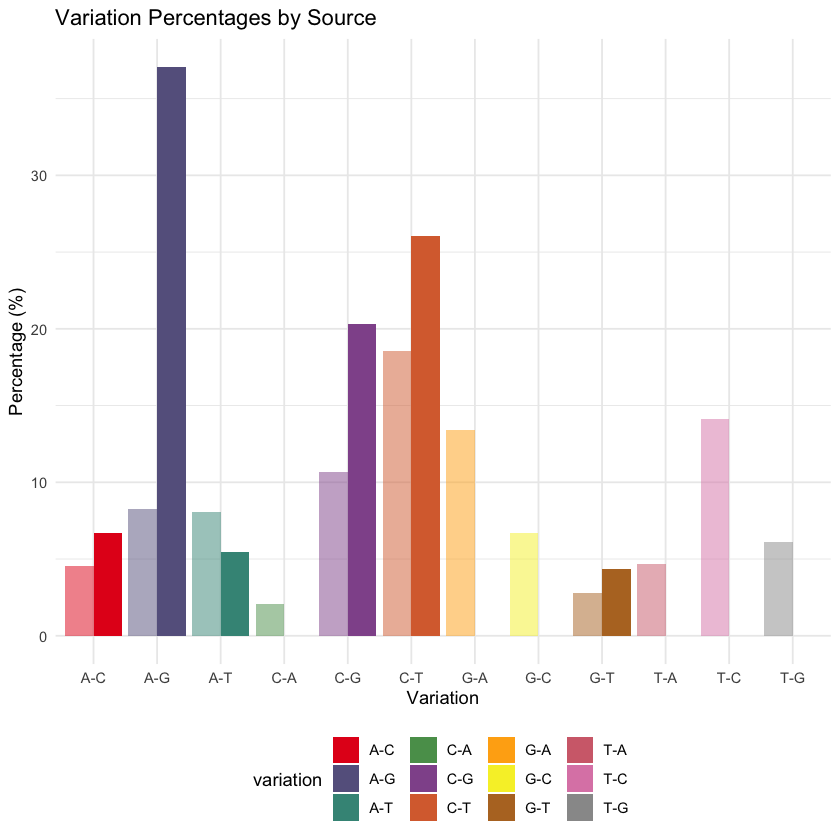

In [25]:
# Generate a color palette with as many colors as there are variation types
my_palette <- colorRampPalette(brewer.pal(9, "Set1"))(length(unique(spectro$variation)))

# Create bar plot
ggplot(spectro_complete, aes(x = variation, y = Percentage, fill = variation, alpha = source)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  scale_alpha_discrete(range = c(0.5, 1), guide = "none") +
  theme_minimal() +
  labs(title = "Variation Percentages by Source", x = "Variation", y = "Percentage (%)") +
  scale_fill_manual(values = my_palette) +
  theme(legend.position = "bottom")


In [26]:
# Filter out variations that aren't present in both sources
spectro_filtered <- spectro %>%
  group_by(variation) %>%
  filter(n() > 1)

# Perform chi-square test for each variation
chi_square_results <- spectro_filtered %>%
  group_by(variation) %>%
  summarise(chisq_test_p_value = chisq.test(n)$p.value)

# Print chi-square test results
print(chi_square_results)

# A tibble: 6 × 2
  variation chisq_test_p_value
  <chr>                  <dbl>
1 A-C                 4.30e- 5
2 A-G                 1.31e-64
3 A-T                 9.31e- 1
4 C-G                 1.08e-18
5 C-T                 1.54e-14
6 G-T                 4.11e- 4


## 4. Calculate proportion FW/CDR in events

In [27]:
subregion <- df_summary %>% group_by(subregion) %>% count() %>% mutate(type = ifelse(str_detect(subregion, "^CDR"), "CDR", "FR"))
subregion

subregion,n,type
<chr>,<int>,<chr>
CDR1,152,CDR
CDR2,45,CDR
CDR3,91,CDR
FR1,284,FR
FR2,324,FR
FR3,302,FR
FR4,41,FR


In [28]:
subregion %>% group_by(type) %>% summarize(n_event=sum(n)) %>% mutate(Percentage =n_event * 100 / sum(n_event))

type,n_event,Percentage
<chr>,<int>,<dbl>
CDR,288,23.24455
FR,951,76.75545


## 5. Calculate the timing of neovariant

In [29]:
events_v3 <- readxl::read_xlsx("output/events.v3.0.xlsx")

In [30]:
events_v31 <- events_v3 %>% 
             mutate(h_from_event = log(original_umis/(original_umis+neovariant1_umis))/-0.231049) 


#### Cell count with neovariants by case

In [31]:
shm_cell_patient <- events_v31 %>% 
   group_by(Sample) %>%
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

Sample,neovariant_cells
<chr>,<int>
S10000,128
S11770,1
S12500,1
S13530,87
S13553,103
S144,40
S8934,4


In [32]:
# Total number of cells

print("Number of TOTAL cells with neovariants")
shm_cell_patient %>% pull(neovariant_cells) %>% sum()

[1] "Number of TOTAL cells with neovariants"


[1] 364

#### Include a numeric cell ID (n_cell_ID)

In [33]:
# Extracting the ID numbers after "S" and creating a consecutive number according to the cellbarcode
events_v31 <- events_v31 %>%
  mutate(sample_number = as.numeric(sub("S", "", Sample))) %>%
  group_by(sample_number) %>%
  mutate(n_cell_ID = paste(sample_number, dense_rank(cell), sep = ".")) %>%
  ungroup() %>%
  select(-sample_number)

In [34]:
datatable(events_v31,
        extensions = 'Buttons', 
          options = list(
            dom = 'Bfrtip',
            buttons = c('colvis'), # Button to show/hide columns
            columnDefs = list(list(targets = '_all', searchable = TRUE)) # Make all columns searchable
          ))

HTML widgets cannot be represented in plain text (need html)

In [35]:
WriteXLS::WriteXLS(events_v31,
                    "output/events.v3.1.xlsx" )

### Incorporate Syn/NonSyn data (pending to check)

In [36]:
df <- Sys.glob("input/results_20230728/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)”


In [57]:
df %>% filter(cell == "ACTTACTGTAGAGGAA", position ==299)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,codon,subregion,aminoacid,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ACTTACTGTAGAGGAA,AAATTATAGT,299,C,C,GC.AT,16,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC
ACTTACTGTAGAGGAA,AACAAAGACC,299,C,T,GC.AT,18,TRUE,V,193,193,a,gc.gt,CxG,FR3,L,K1B_S144-LC
ACTTACTGTAGAGGAA,AATGAGGTGA,299,C,C,GC.AT,6,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC
ACTTACTGTAGAGGAA,ACCGTGACGA,299,C,T,GC.AT,14,TRUE,V,193,193,a,gc.gt,CxG,FR3,L,K1B_S144-LC
ACTTACTGTAGAGGAA,ACTGATGCGG,299,C,C,GC.AT,5,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC
ACTTACTGTAGAGGAA,AGCACCAACA,299,C,C,GC.AT,11,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC
ACTTACTGTAGAGGAA,AGCGGGGGCG,299,C,C,GC.AT,14,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC
ACTTACTGTAGAGGAA,AGGAAATCAC,299,C,C,GC.AT,7,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC
ACTTACTGTAGAGGAA,ATCTTGCTAT,299,C,C,GC.AT,13,TRUE,V,193,193,a,gc.gt,CxG,FR3,P,K1B_S144-LC


In [83]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v32 <- events_v31 %>% left_join(df %>% select(subject,cell,subregion,position,codon,aminoacid,nucl), by=c("subject","cell","subregion","position")) %>% unique() %>% 
mutate(aminoacid_original=if_else(nucl == original, aminoacid,NA)) %>% 
mutate(aminoacid_n1=if_else(nucl == neovariant1, aminoacid,NA)) %>%
mutate(aminoacid_n2=if_else(nucl == neovariant2, aminoacid,NA)) %>%
 group_by(order,Chip,Sample,`Ig Chain`,	`V(D)Jmutations`,	`VDJmutations`,
          `VJmutations`,`inBoth`,`Cell ident`,subject,cell,subregion,position,vgene_position_aligned,
          context_po,aid_motif,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon) %>%
  summarise(
    aminoacid_original = na.omit(aminoacid_original)[1],
    aminoacid_n1 = na.omit(aminoacid_n1)[1],
    aminoacid_n2 = na.omit(aminoacid_n2)[1],
    .groups = 'drop' # to drop the grouping after summarising
  ) %>% mutate(
    mutation_type = case_when(
      aminoacid_original == aminoacid_n1 ~ "silent",
      (!is.na(aminoacid_original)) & aminoacid_n1 == "*" ~ "nonsense",
      aminoacid_original == "*" ~ "stop-loss",
      aminoacid_original != aminoacid_n1 ~ "missense",
      TRUE ~ NA_character_
    )
  )
events_v32

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,aid_motif,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,NA,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,xTG,V,L,NA,missense
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,NA,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,xGA,R,R,NA,silent
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,NA,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,xTA,V,L,NA,missense
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,WA,NA,A,C,NA,12,13,TRUE,NA,10000.2,xAG,NA,K,Q,NA
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,RCG,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,xGA,G,R,NA,missense
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,WRCY,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,GGx,G,G,NA,silent
7,K7B,S10000,L,3,0,3,FALSE,S10000.2,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,174,66,TG.AC,WA,C,T,NA,16,39,NA,TRUE,5.344081,10000.3,TGx,C,C,NA,silent
8,K7B,S10000,L,3,0,3,FALSE,S10000.3,K7B_S10000-LC,AAAGTAGAGGGTTTCT,CDR1,185,77,CA.CT,WRCY,G,A,NA,38,15,NA,TRUE,1.439979,10000.3,AxC,S,N,NA,missense
9,K7B,S10000,H,3,3,0,FALSE,S10000.1,K7B_S10000-HC,AAATGCCTCGAGGTAG,CDR2,291,174,AA.TA,WRCY,A,G,NA,29,14,NA,TRUE,1.704852,10000.4,AAx,K,K,NA,silent


In [84]:
datatable(events_v32,
        extensions = 'Buttons', 
          options = list(
            dom = 'Bfrtip',
            buttons = c('colvis'), # Button to show/hide columns
            columnDefs = list(list(targets = '_all', searchable = TRUE)) # Make all columns searchable
          ))

HTML widgets cannot be represented in plain text (need html)

### Incorporate Nucleotide PO in context

In [51]:
df <- Sys.glob("input/results_20230728/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)”


In [52]:
events_v31 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [58]:
events_v32 <- events_v31 %>% left_join(df %>% select(subject,cell,subregion,position,nucl_po), by=c("subject","cell","subregion","position")) %>% unique() %>%
              mutate(nucl_po = toupper(nucl_po)) %>% mutate(context_po_coding_strand = stri_replace_first_fixed(context_po, ".", nucl_po)) %>%
              mutate(new_context=case_when(!is.na(original) ~ stri_replace_first_fixed(context_po, ".", neovariant1),
                                           TRUE ~ NA))

In [76]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v32 #%>% select(context_po, original, neovariant1,motif_identification,aid_motifs,motif_status)

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,aid_motif,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,nucl_po,context_po_coding_strand,new_context,motif_identification,aid_motifs,motif_status
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<list>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,NA,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,G,CAGTG,CACTG,"None, None",None,None
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,NA,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,A,GCAGA,GCCGA,"None, None",None,None
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,NA,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,G,CTGTA,CTCTA,"None, None",None,None
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,WA,NA,A,C,NA,12,13,TRUE,NA,10000.2,G,CTGAG,NA,"None, None",None,None
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,RCG,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,G,GAGGA,GACGA,"None, None",None,None
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,WRCY,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,G,GGGCA,GGACA,"None, None",None,None
7,K7B,S10000,L,3,0,3,FALSE,S10000.2,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,174,66,TG.AC,WA,C,T,NA,16,39,NA,TRUE,5.344081,10000.3,C,TGCAC,TGTAC,"None, None",None,None
8,K7B,S10000,L,3,0,3,FALSE,S10000.3,K7B_S10000-LC,AAAGTAGAGGGTTTCT,CDR1,185,77,CA.CT,WRCY,G,A,NA,38,15,NA,TRUE,1.439979,10000.3,G,CAGCT,CAACT,"None, None",None,None
9,K7B,S10000,H,3,3,0,FALSE,S10000.1,K7B_S10000-HC,AAATGCCTCGAGGTAG,CDR2,291,174,AA.TA,WRCY,A,G,NA,29,14,NA,TRUE,1.704852,10000.4,A,AAATA,AAGTA,"None, None",None,None


In [83]:
identify_aid_patterns <- function(context_po, original_base, neovariant, verbose = FALSE) {
  
  if (is.na(context_po) || is.na(original_base) || is.na(neovariant)) {
    return(c("NA", "NA"))
  }
  
  if (verbose) {
    cat("Context:", context_po, "\n")
    cat("Original base:", original_base, "\n")
    cat("Neovariant:", neovariant, "\n")
  }
  
  # Define AID motifs and their regular expression patterns
  aid_patterns <- list(
    "WRCY" = list(f = "[AT][AG]C[CT]", r = "[AG]G[CT][AT]"),
    "WA" = list(f = "[AT]A", r = "T[AT]"),
    "RCG" = list(f = "[AG]CG", r = "CG[CT]")
  )
  
  identified_motifs <- c()
  
  # Loop through each AID motif and check for its presence in the context
  for (motif in names(aid_patterns)) {
    if (verbose) cat("Checking motif:", motif, "\n")
    forward_pattern <- paste0(".{2}", aid_patterns[[motif]]$f, ".{2}")
    reverse_pattern <- paste0(".{2}", aid_patterns[[motif]]$r, ".{2}")
    if (grepl(forward_pattern, context_po) || grepl(reverse_pattern, context_po)) {
      identified_motifs <- c(identified_motifs, motif)
    }
  }
  
  if (length(identified_motifs) == 0) {
    return(c("None", "None"))
  }
  
  top_match <- identified_motifs[1]
  
  forward_pattern <- paste0(".{2}", aid_patterns[[top_match]]$f, ".{2}")
  reverse_pattern <- paste0(".{2}", aid_patterns[[top_match]]$r, ".{2}")
  
  if (grepl(forward_pattern, context_po) || grepl(reverse_pattern, context_po)) {
    if (original_base == neovariant) {
      return(c(top_match, "Conserved"))
    } else {
      return(c(top_match, "Destroyed"))
    }
  }
}


In [84]:
# Apply the function and extract the results
events_v32_annotated <- events_v32 %>%
  rowwise() %>%
  mutate(motif_identification = list(identify_aid_patterns(context_po, original, neovariant1, verbose = FALSE))) %>%
  ungroup() %>%
  mutate(aid_motifs = map_chr(motif_identification, 1),
         motif_status = map_chr(motif_identification, 2))

# Check the first few rows to see the new columns
head(events_v32_annotated)


order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,aid_motif,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,nucl_po,context_po_coding_strand,new_context,motif_identification,aid_motifs,motif_status
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<list>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,NA,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,G,CAGTG,CACTG,"None, None",None,None
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,NA,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,A,GCAGA,GCCGA,"None, None",None,None
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,NA,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,G,CTGTA,CTCTA,"None, None",None,None
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,WA,NA,A,C,NA,12,13,TRUE,NA,10000.2,G,CTGAG,NA,"NA, NA",NA,NA
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,RCG,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,G,GAGGA,GACGA,"None, None",None,None
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,WRCY,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,G,GGGCA,GGACA,"None, None",None,None


In [70]:
events_v32_annotated %>% select(context_po,original,neovariant1,motif_identification,aid_motifs,motif_status)

context_po,original,neovariant1,motif_identification,aid_motifs,motif_status
<chr>,<chr>,<chr>,<list>,<chr>,<chr>
CA.TG,G,C,"WRCY, De....",WRCY,Destroyed
GC.GA,A,C,"WRCY, De....",WRCY,Destroyed
CT.TA,G,C,"WRCY, De....",WRCY,Destroyed
CT.AG,NA,A,"WRCY, De....",WRCY,Destroyed
GA.GA,G,C,"WRCY, De....",WRCY,Destroyed
GG.CA,G,A,"WRCY, De....",WRCY,Destroyed
TG.AC,C,T,"WRCY, De....",WRCY,Destroyed
CA.CT,G,A,"WRCY, Co....",WRCY,Conserved
AA.TA,A,G,"WRCY, Co....",WRCY,Conserved


In [136]:
# AID patterns; f/r = forward/reverse, c = context
aidp <- list(
  WRCY = list(f.c = "[ACTG][ACTG][AT][AG]C[CT]", r.c = "[ACTG][ACTG][AG]G[CT][AT]"),
  WA = list(f.c = "[ACTG][ACTG][AT]A[ACGT]", r.c = "[ACTG][ACTG][ACGT]T[AT]"),
  RCG = list(f.c = "[ACTG][ACTG][AG]CG", r.c = "[ACTG][ACTG]CG[CT]")
)


In [154]:
# Function to get the reverse complement of a DNA sequence
reverse_complement <- function(seq) {
  rc_map <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  rc_seq <- paste(rev(rc_map[unlist(strsplit(seq, ""))]), collapse = "")
  return(rc_seq)
}

identify_AID_motif <- function(context, original, neovariant1) {
  if (is.na(context) || is.na(original) || is.na(neovariant1)) {
    return(list(NA, NA, NA))
  }
  
  # Replace the period with the original nucleotide
  full_context_original <- gsub("\\.", original, context)
  
  # Replace the period with the neovariant nucleotide
  full_context_neovariant <- gsub("\\.", neovariant1, context)
  
  # Get reverse complements
  rc_context_original <- reverse_complement(full_context_original)
  rc_context_neovariant <- reverse_complement(full_context_neovariant)
  
  # Initialize variables
  motif <- NA
  strand <- NA
  destroyed <- NA
  
  # AID patterns; f/r = forward/reverse, c = context
  aidp <- list(
    WRCY = list(f.c = "[ACTG][ACTG][AT][AG]C[CT]", r.c = "[ACTG][ACTG][AG]G[CT][AT]"),
    WA = list(f.c = "[ACTG][ACTG][AT]A[ACGT]", r.c = "[ACTG][ACTG][ACGT]T[AT]"),
    RCG = list(f.c = "[ACTG][ACTG][AG]CG", r.c = "[ACTG][ACTG]CG[CT]")
  )
  
  # Check for motifs
  for (m_name in names(aidp)) {
    motif_patterns <- aidp[[m_name]]
    for (strand_type in names(motif_patterns)) {
      motif_pattern <- motif_patterns[[strand_type]]
      
      if (grepl(motif_pattern, full_context_original) || grepl(motif_pattern, rc_context_original)) {
        motif <- m_name
        strand <- ifelse(strand_type == "f.c", "forward", "reverse")
        
        # Check if the motif is destroyed by the mutation
        destroyed <- ifelse(grepl(motif_pattern, full_context_neovariant) || grepl(motif_pattern, rc_context_neovariant), "No", "Yes")
        
        return(list(motif, strand, destroyed))
      }
    }
  }
  
  return(list(NA, NA, NA))
}


In [155]:
events_v32  <- events_v32 %>% 
  rowwise() %>%
  do({
    res <- identify_AID_motif(.$context_po, .$original, .$neovariant1)
    data.frame(., motif=res[[1]], strand=res[[2]], destroyed=res[[3]])
  })



In [197]:

# Function to identify AID motifs
identify_AID_motif <- function(context, original, neovariant1) {
  if (is.na(context) || is.na(original) || is.na(neovariant1)) {
    return(list(NA, NA, NA))
  }
  
  # Replace the '.' in the context with the original and neovariant nucleotides
  full_context_original <- gsub("\\.", original, context)
  full_context_neovariant <- gsub("\\.", neovariant1, context)
  
  # Get the reverse complement of the full context
  rc_context_original <- reverse_complement(full_context_original)
  rc_context_neovariant <- reverse_complement(full_context_neovariant)
  
  # Define motifs and their reverse complements
  motifs <- list(
    WRCY = c(forward = "[AT][AG]C[CT]", reverse = "[AG]G[CT][AT]"),
    WA = c(forward = "[AT]A[ACGT]", reverse = "[ACTG]T[AT]"),
    RCG = c(forward = "[AG]CG", reverse = "CG[CT]")
  )
  
  # Check for motifs
  for (m_name in names(motifs)) {
    for (strand in names(motifs[[m_name]])) {
      motif_pattern <- motifs[[m_name]][[strand]]
      context_to_use <- if (strand == "forward") full_context_original else rc_context_original
      neovariant_to_use <- if (strand == "forward") full_context_neovariant else rc_context_neovariant
      
      # Find the positions of the original nucleotide in the context
      positions <- gregexpr(original, context_to_use)[[1]]
      if (positions[1] == -1) {
        next
      }
      
      # Check if the context around each position matches the motif
      for (pos in positions) {
        start_pos = max(1, pos - 2)
        end_pos = min(nchar(context_to_use), pos + 2)
        substring = substr(context_to_use, start_pos, end_pos)
        
        if (grepl(motif_pattern, substring)) {
          destroyed = ifelse(grepl(motif_pattern, substr(neovariant_to_use, start_pos, end_pos)), "No", "Yes")
          return(list(m_name, if (strand == "forward") "forward" else "reverse", destroyed))
        }
      }
    }
  }
  
  return(list(NA, NA, NA))
}

In [198]:
events_v32 <- events_v32 %>%
  mutate(motif_identifications = pmap(list(context_po, original, neovariant1), identify_AID_motif))

events_v32 <- events_v32 %>%
  mutate(
    first_found_motif = map_chr(motif_identifications, ~ if(length(.x) > 0 && length(.x[[1]]) >= 1) .x[[1]][[1]] else NA),
    first_found_strand = map_chr(motif_identifications, ~ if(length(.x) > 0 && length(.x[[1]]) >= 2) .x[[1]][[2]] else NA),
    first_found_destroyed = map_chr(motif_identifications, ~ if(length(.x) > 0 && length(.x[[1]]) >= 3) .x[[1]][[3]] else NA)
  )

In [199]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v32

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,aid_motif,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,nucl_po,context_po_coding_strand,new_context,motif_identifications,first_found_motif,first_found_strand,first_found_destroyed
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<list>,<chr>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,NA,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,G,CAGTG,CACTG,"NA, NA, NA",NA,NA,NA
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,NA,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,A,GCAGA,GCCGA,"NA, NA, NA",NA,NA,NA
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,NA,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,G,CTGTA,CTCTA,"NA, NA, NA",NA,NA,NA
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,WA,NA,A,C,NA,12,13,TRUE,NA,10000.2,G,CTGAG,NA,"NA, NA, NA",NA,NA,NA
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,RCG,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,G,GAGGA,GACGA,"NA, NA, NA",NA,NA,NA
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,WRCY,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,G,GGGCA,GGACA,"NA, NA, NA",NA,NA,NA
7,K7B,S10000,L,3,0,3,FALSE,S10000.2,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,174,66,TG.AC,WA,C,T,NA,16,39,NA,TRUE,5.344081,10000.3,C,TGCAC,TGTAC,"NA, NA, NA",NA,NA,NA
8,K7B,S10000,L,3,0,3,FALSE,S10000.3,K7B_S10000-LC,AAAGTAGAGGGTTTCT,CDR1,185,77,CA.CT,WRCY,G,A,NA,38,15,NA,TRUE,1.439979,10000.3,G,CAGCT,CAACT,"WRCY, fo....",WRCY,NA,NA
9,K7B,S10000,H,3,3,0,FALSE,S10000.1,K7B_S10000-HC,AAATGCCTCGAGGTAG,CDR2,291,174,AA.TA,WRCY,A,G,NA,29,14,NA,TRUE,1.704852,10000.4,A,AAATA,AAGTA,"WA, forw....",WA,NA,NA
